# MAGI version 0.8 — Energy line-mixture head (beta)

v0.8 replaces the categorical/binned energy head with a continuum + fixed-line
mixture head. See `docs/v0.8_beta_plan.md` for the full design and
`docs/v0.8_IAF_integration_plan.md` for the (out-of-scope for v0.8) latent-flow
track.

This notebook is a new, standalone pipeline for v0.8 — it does not modify or
depend on `MAGI_v0_7_2.ipynb`, so the current v0.7.2 model stays untouched.
It is meant to be extended in place as each phase of the beta plan lands:

- **Phase A (this section)**: detect which physical spectral lines are
  actually present in the real training data, using
  `magi.detect_energy_lines` against `magi.CANDIDATE_ENERGY_LINES`.
- **Phase B+**: mixture-density energy head, two-stage generation sampling,
  adaptive-callback updates, generation validation — added as later
  sections once implemented.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import magi

magi.initialize_environment(seed=42)
magi.set_plot_theme("light")

print(magi.__file__)
print(magi.__version__)

/Volumes/X10Pro/MAGI/MAGI_package/magi/__init__.py
0.7.2


## Load real training data

One file per background component (see `CLAUDE.md` for the data layout).

In [2]:
TRAINING_DATA_DIR = "/Volumes/X10Pro/MAGI/TrainingData"

# One .dat file per background component that went into the CryoSphere
# simulation (cosmic rays: muons/gammas/electrons, continuum only; the two
# radioactive components: concrete-embedded sources, decay lines expected -
# see CANDIDATE_ENERGY_LINES for which chain each file is expected to carry).
SOURCE_FILES = {
    "CR": f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereCR.dat",
    "Radio": f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereRadio.dat",
    "Torio": f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereTorio.dat",
}

center = (0.0, 0.0, -507.66)
R = 100.0

energies = {}
for name, path in SOURCE_FILES.items():
    df = magi.load_detector_table(filepath=path, sep=r"\s+")
    prep = magi.build_physical_features(df, center=center, radius=R)
    energies[name] = prep["features"]["Energy"].to_numpy()
    print(f"{name}: {len(df):,} rows, {energies[name].size:,} valid energies, "
          f"E in [{energies[name].min():.4f}, {energies[name].max():.4f}] MeV")

CR: 3,443,885 rows, 3,443,885 valid energies, E in [0.0004, 583511.0000] MeV


Radio: 1,392,031 rows, 1,392,031 valid energies, E in [0.0011, 1.9262] MeV


Torio: 8,847,918 rows, 8,847,918 valid energies, E in [0.0010, 2.5053] MeV


## Phase A — energy line detection

For each source, detect statistically significant peaks in the real energy
spectrum and match them against `magi.CANDIDATE_ENERGY_LINES` (instrumental
fluorescence lines from the gold TES sensor + Al/Cu structure, and the
K-40 / Ra-226-chain / Th-232-chain source decay lines).

Expected (per the prior diagnostic finding, see project memory): the
instrumental lines should mostly show up as `matched_lines`; the source decay
lines should mostly land in `unmatched_candidates`, since sources sit in bulk
shielding and their primary gammas are Compton-degraded before crossing the
CryoSphere.

In [3]:
line_results = {}
for name, E in energies.items():
    print("\n" + "=" * 72)
    print(f"Source: {name}")
    print("=" * 72)
    res = magi.detect_energy_lines(
        E,
        binning_mode="log_fixed_count",
        n_bins=1024,
        prominence_factor=3.0,
        window=5,
    )
    magi.print_detected_energy_lines(res)
    line_results[name] = res


Source: CR



--- Energy line detection ---
events: 3443885  bins: 1024  mode: log_fixed_count
candidate lines: 15  detected peaks: 5  matched: 4

Matched lines:
  e+e- annihilation    (instrumental          ) expected=0.511000 MeV detected=0.509492 MeV delta=-0.001508 MeV  count=61462
  Al Kalpha            (instrumental          ) expected=0.001487 MeV detected=0.001457 MeV delta=-0.000030 MeV  count=10681
  Cu Kalpha            (instrumental          ) expected=0.008048 MeV detected=0.008071 MeV delta=+0.000023 MeV  count=7602
  Cu Kbeta             (instrumental          ) expected=0.008905 MeV detected=0.008948 MeV delta=+0.000043 MeV  count=1505

Expected-but-undetected candidates (likely Compton-smeared / below prominence):
  Au Lalpha            (instrumental          ) expected=0.009713 MeV
  Au Lbeta             (instrumental          ) expected=0.011442 MeV
  K-40                 (source:K-40           ) expected=1.460820 MeV
  Pb-214               (source:Ra-226 chain   ) expected=0.295


--- Energy line detection ---
events: 8847918  bins: 1024  mode: log_fixed_count
candidate lines: 15  detected peaks: 12  matched: 4

Matched lines:
  e+e- annihilation    (instrumental          ) expected=0.511000 MeV detected=0.510272 MeV delta=-0.000728 MeV  count=139953
  Al Kalpha            (instrumental          ) expected=0.001487 MeV detected=0.001464 MeV delta=-0.000023 MeV  count=646
  Cu Kalpha            (instrumental          ) expected=0.008048 MeV detected=0.008031 MeV delta=-0.000017 MeV  count=795
  Cu Kbeta             (instrumental          ) expected=0.008905 MeV detected=0.008868 MeV delta=-0.000037 MeV  count=167

Expected-but-undetected candidates (likely Compton-smeared / below prominence):
  Au Lalpha            (instrumental          ) expected=0.009713 MeV
  Au Lbeta             (instrumental          ) expected=0.011442 MeV
  K-40                 (source:K-40           ) expected=1.460820 MeV
  Pb-214               (source:Ra-226 chain   ) expected=0.29522

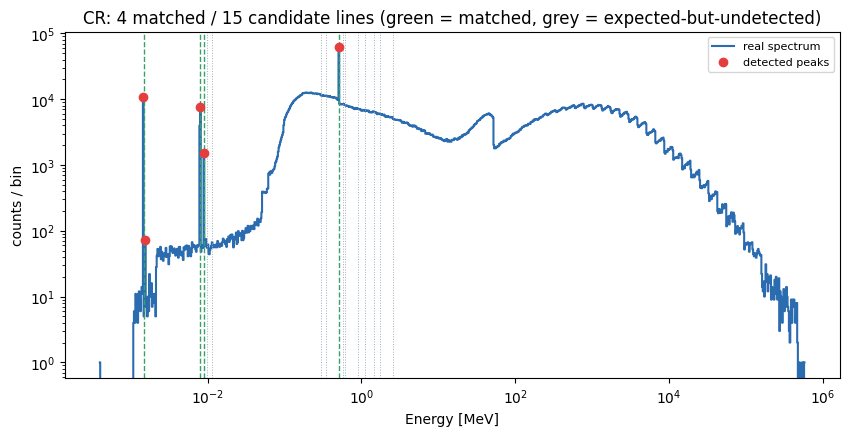

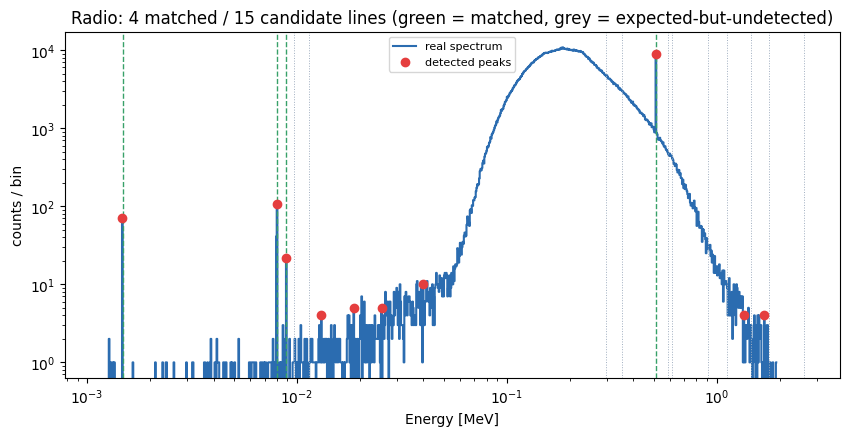

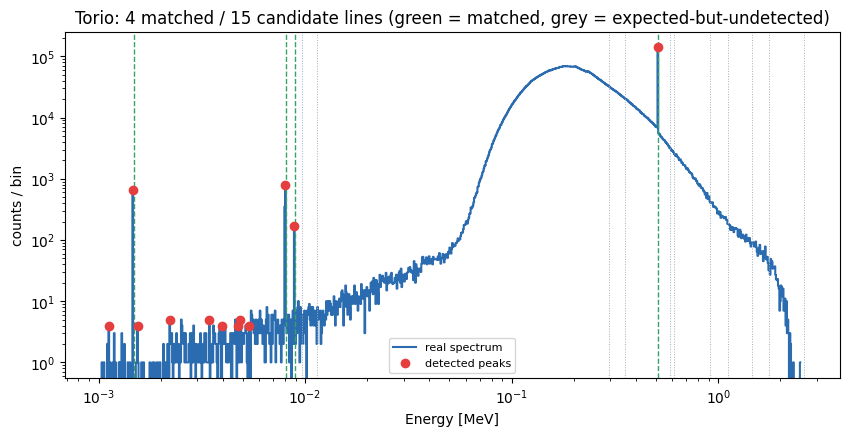

In [4]:
def plot_line_detection(name, E, result):
    edges = np.asarray(result["energy_bins"])
    centres = 0.5 * (edges[:-1] + edges[1:])
    counts, _ = np.histogram(E, bins=edges)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.step(centres, counts, where="mid", color="#2b6cb0", label="real spectrum")

    for m in result["matched_lines"]:
        ax.axvline(m["candidate_energy_mev"], color="#38a169", lw=1, ls="--")
    for c in result["unmatched_candidates"]:
        ax.axvline(c["candidate_energy_mev"], color="#a0aec0", lw=0.7, ls=":")

    peak_e = [p["energy_mev"] for p in result["detected_peaks"]]
    peak_c = [p["count"] for p in result["detected_peaks"]]
    ax.scatter(peak_e, peak_c, color="#e53e3e", zorder=5, label="detected peaks")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel("counts / bin")
    n_matched = result["n_matched"]
    n_candidates = result["n_candidate_lines"]
    ax.set_title(
        f"{name}: {n_matched} matched / {n_candidates} candidate lines "
        "(green = matched, grey = expected-but-undetected)"
    )
    ax.legend(fontsize=8)
    plt.show()


for name, E in energies.items():
    plot_line_detection(name, E, line_results[name])

## Next steps (Phase B+)

`line_results` above is the input Phase B needs to build the mixture-density
energy head's fixed line positions (`line_positions_y`) — see
`docs/v0.8_beta_plan.md` §1-2. This notebook will grow the corresponding
model-build / training / generation / validation sections as those phases
land, mirroring `MAGI_v0_7_2.ipynb`'s structure.